<a href="https://colab.research.google.com/github/turayusa/homework/blob/main/4_2_Activity_Jupyter_Notebook_%E2%80%93_Logistic_Regression_and_Feature_Scalingipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DX799 Data Science Capstone

## Week 4 Jupyter Notebook – Logistic Regression and Feature Scaling

### Predicting Hospital Readmission Among Patients With Diabetes Using Logistic Regression

**Student:** Abdul Karim Turay  
**Course:** DX799 Data Science Capstone  
**Semester:** Fall 2026  
**Week:** Week 4  
**Dataset:** Diabetes Hospitalization Dataset

---

### Project Objective

The objective of this Week 4 analysis is to use logistic regression and feature scaling on the diabetes hospitalization dataset.The analysis will investigate whether patient encounter features can be used to predict hospital readmission. The `readmitted` variable will be converted into a binary outcome indicating whether or not a patient was readmitted.A baseline logistic regression model will be created initially, followed by feature scaling to evaluate its effect on model performance and interpretation. The model's performance will be assessed using classification metrics such as accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

# Table of Contents

1. **Data Preparation and Outcome Definition**
   - 1A. Dataset Loading and Variable Selection
   - 1B. Binary Readmission Outcome
   - 1C. Missing-Value Assessment

2. **Exploratory Analysis of Hospital Readmission**
   - 2A. Readmission Class Distribution
   - 2B. Predictor Summary
   - 2C. Train-Test Split

3. **Baseline Logistic Regression**
   - 3A. Model Development
   - 3B. Classification Performance
   - 3C. Confusion Matrix

4. **Feature Scaling**
   - 4A. Standardization of Predictors
   - 4B. Scaled Logistic Regression Model

5. **Model Evaluation**
   - 5A. Classification Metrics
   - 5B. ROC Curve and AUC
   - 5C. Baseline vs. Scaled Model Comparison

6. **Logistic Regression Coefficient Interpretation**
   - 6A. Model Coefficients
   - 6B. Odds Ratios

7. **Final Conclusion**

# 1. Data Preparation and Outcome Definition

## Objective

The objective of this section is to prepare the diabetes hospitalization dataset for logistic regression analysis.

Unlike the previous analyses that predicted the continuous outcome `time_in_hospital`, Week 4 focuses on a classification problem. The `readmitted` variable will be used to identify whether a patient was readmitted to the hospital.

The dataset will be loaded, the necessary predictors will be selected, and the readmission outcome will be transformed into a binary variable suitable for logistic regression.

## 1A. Dataset Loading and Variable Selection

The diabetes hospitalization dataset is loaded and examined before model development. Seven continuous patient encounter variables used in the previous analyses are retained as predictors so that the Week 4 classification analysis remains connected to the earlier regression analyses.

The predictors are:

- `num_lab_procedures`
- `num_procedures`
- `num_medications`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`
- `number_diagnoses`

The original `readmitted` variable is retained as the outcome for subsequent binary classification.

In [52]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
import io

# Upload the diabetes dataset
uploaded = files.upload()

# Identify the uploaded file
filename = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Define predictor variables
features = [
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Select predictors and original outcome
week4_variables = features + ['readmitted']
df_week4 = df[week4_variables].copy()

# Display dataset information
print("File loaded:", filename)
print("Original dataset shape:", df.shape)
print("Week 4 dataset shape:", df_week4.shape)

print("\nFirst five observations:")
display(df_week4.head())

Saving diabetic_data.csv to diabetic_data (3).csv
File loaded: diabetic_data (3).csv
Original dataset shape: (101766, 50)
Week 4 dataset shape: (101766, 8)

First five observations:


,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
0,41,0,1,0,0,0,1,NO
1,59,0,18,0,0,0,9,>30
2,11,5,13,2,0,1,6,NO
3,44,1,16,0,0,0,7,NO
4,51,0,8,0,0,0,5,NO


### Analysis

The original diabetes hospitalization dataset consists of 101,766 observations and 50 variables. For the Week 4 logistic regression analysis, seven continuous predictors and the `readmitted` outcome were selected, yielding a working dataset of 101,766 observations and 8 variables.

The selected predictors describe healthcare utilization and hospital encounter characteristics and will be examined to determine whether they can help predict hospital readmission.

## 1B. Binary Readmission Outcome

The original `readmitted` variable has three categories that indicate whether a patient was readmitted within 30 days, after 30 days, or not readmitted.

For this analysis, the outcome is transformed into a binary classification variable:

- **1 = Readmitted** (`<30` or `>30`)
- **0 = Not Readmitted** (`NO`)

Combining the two readmission categories allows logistic regression to model the likelihood of a patient having any hospital readmission.

In [53]:
# Examine the original readmission categories
print("Original readmission categories:")
print(df_week4['readmitted'].value_counts())

# Create binary readmission outcome
df_week4['readmitted_binary'] = np.where(
    df_week4['readmitted'] == 'NO',
    0,
    1
)

# Display binary outcome counts and percentages
readmission_counts = df_week4['readmitted_binary'].value_counts().sort_index()
readmission_percent = (
    df_week4['readmitted_binary'].value_counts(normalize=True)
    .sort_index() * 100
)

readmission_summary = pd.DataFrame({
    'Count': readmission_counts,
    'Percentage': readmission_percent
})

readmission_summary.index = ['Not Readmitted (0)', 'Readmitted (1)']

print("\nBinary Readmission Outcome:")
display(readmission_summary.round(2))

Original readmission categories:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary Readmission Outcome:


,Count,Percentage
Not Readmitted (0),54864,53.91
Readmitted (1),46902,46.09


### Analysis

The original readmission variable included three categories: 54,864 patients were not readmitted (`NO`), 35,545 were readmitted after 30 days (`>30`), and 11,357 were readmitted within 30 days (`<30`).

After converting the outcome to binary format, 54,864 patients (53.91%) were classified as not readmitted, while 46,902 patients (46.09%) were classified as readmitted.

The two outcome classes are relatively balanced, with only a slight difference in proportions. As a result, the dataset can be used to build a binary logistic regression model without the immediate need for class-balancing techniques.

## 1C. Missing-Value Assessment

### Objective

Before fitting the logistic regression model, the selected predictors and binary outcome are checked for missing values. Identifying missing observations is important because logistic regression requires complete predictor and outcome data for model training and evaluation.

In [54]:
# Variables used for logistic regression
model_variables = features + ['readmitted_binary']

# Check missing values
missing_values = df_week4[model_variables].isnull().sum()

print("Missing Values in Week 4 Modeling Variables:")
print(missing_values)

# Create clean modeling dataset
df_model = df_week4[model_variables].dropna().copy()

print("\nObservations before cleaning:", len(df_week4))
print("Observations after cleaning:", len(df_model))
print("Observations removed:", len(df_week4) - len(df_model))

Missing Values in Week 4 Modeling Variables:
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
readmitted_binary     0
dtype: int64

Observations before cleaning: 101766
Observations after cleaning: 101766
Observations removed: 0


### Analysis

The missing-value assessment revealed that none of the seven predictor variables or the binary readmission outcome had missing values.

As a result, all 101,766 observations were retained for the Week 4 logistic regression analysis, and none were removed. This provides a complete dataset for model building and evaluation.

# 2. Exploratory Analysis of Hospital Readmission

## 2A. Readmission Class Distribution

### Objective

The objective of this subsection is to examine the distribution of the binary hospital readmission outcome before developing the logistic regression models.

Examining the class distribution helps determine whether the readmitted and non-readmitted groups are reasonably balanced and whether substantial class imbalance may affect model development.

In [55]:
# Calculate binary readmission counts and percentages
class_counts = df_model['readmitted_binary'].value_counts().sort_index()

class_percentages = (
    df_model['readmitted_binary']
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Create class distribution summary
class_distribution = pd.DataFrame({
    "Class": ["Not Readmitted (0)", "Readmitted (1)"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

print("Hospital Readmission Class Distribution:")
display(class_distribution.round(2))

Hospital Readmission Class Distribution:


,Class,Count,Percentage
0,Not Readmitted (0),54864,53.91
1,Readmitted (1),46902,46.09


## 2A. Analysis

The binary readmission outcome included 54,864 patients (53.91%) who were not readmitted and 46,902 patients (46.09%) who were readmitted.

The two classes were relatively balanced, although the not-readmitted group was slightly larger. This distribution does not indicate substantial class imbalance, allowing logistic regression models to be developed without the immediate need for class-balancing techniques.

## 2B. Predictor Summary

### Objective

The objective of this subsection is to summarize the seven predictor variables used to model hospital readmission.

Descriptive statistics are used to examine the central tendency, variability, and range of the predictors before logistic regression modeling.

In [56]:
# Generate descriptive statistics for the seven predictors
predictor_summary = df_model[features].describe().T

# Retain key descriptive statistics
predictor_summary = predictor_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

print("Summary Statistics for Predictor Variables:")
display(predictor_summary.round(2))

Summary Statistics for Predictor Variables:


,count,mean,std,min,25%,50%,75%,max
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


## 2B. Analysis

The descriptive statistics show substantial differences in the distributions and numerical scales of the seven predictor variables across 101,766 observations. `num_lab_procedures` had the highest mean at 43.10 procedures (SD = 19.67), followed by `num_medications` with a mean of 16.02 (SD = 8.13) and `number_diagnoses` with a mean of 7.42 (SD = 1.93). The mean number of procedures was 1.34 (SD = 1.71).

Previous healthcare utilization was generally low: `number_outpatient`, `number_emergency`, and `number_inpatient` had means of 0.37, 0.20, and 0.64, respectively. Their medians for outpatient, emergency, and inpatient visits were zero, indicating that many patients had no encounters in these settings.

The predictors' ranges also varied substantially. For example, `num_lab_procedures` ranged from 1 to 132, `number_emergency` from 0 to 76, and `number_outpatient` from 0 to 42. These differences in numerical scales support the use of feature standardization later in Section 4 before fitting the scaled logistic regression model.

## 2C. Train-Test Split

### Objective

The objective of this subsection is to separate the dataset into training and testing sets for logistic regression model development and evaluation.

An 80/20 train-test split is used with stratification to maintain the proportion of readmitted and non-readmitted patients in both sets. A fixed random state is used to ensure reproducibility.

In [57]:
# Prepare predictors and outcome for model development
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model['readmitted_binary']

# Create stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 81412
Testing observations: 20354


## 2C. Analysis

The dataset was split into 81,412 training observations and 20,354 testing observations using an 80/20 train-test ratio.

To preserve the proportions of readmitted and non-readmitted patients in both sets, stratification was used with the binary readmission outcome. The training data will be used to fit the model, while the testing data will be used to evaluate model performance on observations that were not used during model training.

# 3. Baseline Logistic Regression

## 3A. Model Development

### Objective

The objective of this subsection is to develop a baseline logistic regression model to predict hospital readmission using the seven selected predictor variables before feature scaling.

Logistic regression is appropriate because the outcome is binary, with 0 representing patients who were not readmitted and 1 representing patients who were readmitted.

The baseline model is trained using the original unscaled training predictors and evaluated using the original unscaled testing predictors. This model will later be compared with the scaled logistic regression model to determine whether feature scaling affects classification performance.

In [58]:
# Import logistic regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create baseline logistic regression model
baseline_logistic_model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Train the baseline model using unscaled training predictors
baseline_logistic_model.fit(X_train, y_train)

# Predict classes using unscaled test predictors
y_pred_baseline = baseline_logistic_model.predict(X_test)

# Predict probabilities for Readmitted = 1
y_prob_baseline = baseline_logistic_model.predict_proba(X_test)[:, 1]

# Calculate baseline performance metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)

# Display baseline model performance
print("Baseline Logistic Regression Performance")
print("Accuracy:", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1-score:", round(baseline_f1, 4))
print("ROC-AUC:", round(baseline_auc, 4))

# Display classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Not Readmitted (0)", "Readmitted (1)"]
))

Baseline Logistic Regression Performance
Accuracy: 0.6191
Precision: 0.6448
Recall: 0.3863
F1-score: 0.4832
ROC-AUC: 0.6473

Classification Report:
                    precision    recall  f1-score   support

Not Readmitted (0)       0.61      0.82      0.70     10973
    Readmitted (1)       0.64      0.39      0.48      9381

          accuracy                           0.62     20354
         macro avg       0.63      0.60      0.59     20354
      weighted avg       0.63      0.62      0.60     20354



### 3A. Analysis

The baseline logistic regression model was successfully fitted using the original unscaled predictor variables. The model used the same training and testing observations, allowing its performance to be directly compared with the scaled logistic regression model later in the analysis.

The baseline model had an accuracy of 0.6191 and a ROC-AUC of 0.6473, indicating that approximately 61.9% of the test observations were correctly classified and that the model had modest ability to distinguish between readmitted and non-readmitted patients.

Section 3B provides a more detailed evaluation of the remaining classification metrics, including precision, recall, and F1-score.

## 3B. Classification Performance

### Analysis

The baseline logistic regression model had an accuracy of 0.6191, which means that approximately 61.9% of the test observations were correctly classified.

For the readmitted class, the model attained a precision of 0.6448, indicating that approximately 64.5% of patients predicted to be readmitted were actually readmitted. The recall was 0.3863, which means that the model correctly identified approximately 38.6% of patients who were readmitted.

The F1-score was 0.4832, indicating the balance between precision and recall. The model also had a ROC-AUC of 0.6473, demonstrating modest ability to distinguish between readmitted and non-readmitted patients.

Overall, the baseline model was more effective at identifying patients who were not readmitted than those who were readmitted. The relatively low recall for the readmitted class suggests that the model missed a substantial proportion of patients who were readmitted.

## 3C. Confusion Matrix

### Objective

This subsection will use a confusion matrix to assess the classification performance of the baseline logistic regression model.

The confusion matrix displays the number of true negatives, false positives, false negatives, and true positives, allowing for a more detailed evaluation of how effectively the model distinguishes between readmitted and non-readmitted patients.

Baseline Logistic Regression Confusion Matrix:
[[8977 1996]
 [5757 3624]]


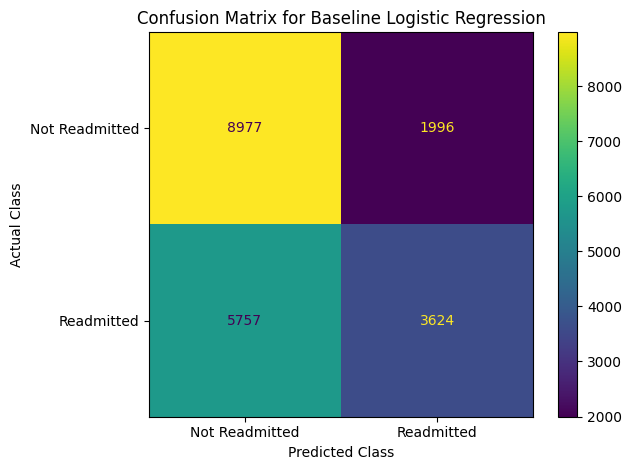

In [59]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate baseline confusion matrix
cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

# Display numerical confusion matrix
print("Baseline Logistic Regression Confusion Matrix:")
print(cm_baseline)

# Visualize baseline confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["Not Readmitted", "Readmitted"]
).plot(values_format="d")

plt.title("Confusion Matrix for Baseline Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.show()
plt.close()

### 3C. Analysis

The confusion matrix provides a detailed evaluation of the baseline logistic regression model's classification performance.

The model identified 8,977 patients as not readmitted (true negatives) and 3,624 patients as readmitted (true positives). However, 1,996 patients who were not readmitted were incorrectly classified as readmitted (false positives), while 5,757 patients who were readmitted were incorrectly classified as not readmitted (false negatives).

The relatively high number of false negatives indicates that the baseline model missed many patients who were actually readmitted. This is consistent with the recall of 0.3863 observed for the readmitted class.

Overall, the confusion matrix indicates that the baseline logistic regression model was more effective at identifying patients who were not readmitted than those who were readmitted.

# 4. Feature Scaling

## 4A. Predictor Standardization

### Objective

The objective of this subsection is to standardize the seven predictor variables before developing the scaled logistic regression model.

Standardization transforms predictors measured on different numerical scales, resulting in training predictors with a mean of approximately 0 and a standard deviation of approximately 1. This enables the predictors to be represented on a similar scale.

To avoid data leakage, the `StandardScaler` is fitted solely to the training data. The fitted scaler is then used to transform both the training and testing predictors.

In [60]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler using the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the fitted training scaler
X_test_scaled = scaler.transform(X_test)

# Verify standardization of the training predictors
scaling_summary = pd.DataFrame({
    "Predictor": features,
    "Mean After Scaling": X_train_scaled.mean(axis=0),
    "Standard Deviation After Scaling": X_train_scaled.std(axis=0)
})

print("Standardization Summary for Training Predictors:")
display(scaling_summary.round(4))

Standardization Summary for Training Predictors:


,Predictor,Mean After Scaling,Standard Deviation After Scaling
0,num_lab_procedures,0.0,1.0
1,num_procedures,0.0,1.0
2,num_medications,-0.0,1.0
3,number_outpatient,0.0,1.0
4,number_emergency,-0.0,1.0
5,number_inpatient,0.0,1.0
6,number_diagnoses,0.0,1.0


### 4A. Analysis

The standardization results show that all seven training predictor variables were standardized effectively. After scaling, each training predictor had a mean close to zero and a standard deviation of one.

This places the predictors on a common scale, despite differences in their original units and ranges. The scaler was fitted using only the training data and then applied to the testing data, so information from the test set did not influence model development.

The standardized predictors are now ready to be used in the scaled logistic regression model.

## 4B. Scaled Logistic Regression Model

### Objective

The objective of this subsection is to create a logistic regression model using standardized predictor variables.

The scaled training predictors are used to train the model, while the scaled testing predictors are used to evaluate its performance. The model's performance will then be compared with the baseline logistic regression model to determine whether feature scaling has an impact on classification performance.

In [61]:
# Create scaled logistic regression model
scaled_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using standardized training predictors
scaled_logistic_model.fit(X_train_scaled, y_train)

# Generate class predictions
y_pred_scaled = scaled_logistic_model.predict(X_test_scaled)

# Generate predicted probabilities for Readmitted = 1
y_prob_scaled = scaled_logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Scaled Logistic Regression Model Successfully Trained")
print("Training observations:", X_train_scaled.shape[0])
print("Testing observations:", X_test_scaled.shape[0])
print("Number of predictors:", X_train_scaled.shape[1])

Scaled Logistic Regression Model Successfully Trained
Training observations: 81412
Testing observations: 20354
Number of predictors: 7


### 4B. Analysis

The scaled logistic regression model was successfully fitted using 81,412 training observations and evaluated using 20,354 testing observations. The model includes all seven standardized predictor variables.

The successful model fitting confirms that the standardized predictors can be used to assess hospital readmission classification performance. The predictive performance of this scaled model will be evaluated in the following section using classification metrics and compared with the baseline logistic regression model.

# 5. Model Evaluation

## 5A. Classification Metrics

### Objective

This subsection will assess the scaled logistic regression model's classification performance.

Accuracy, precision, recall, and F1-score will be calculated to evaluate different aspects of model performance. These metrics assess the model's overall classification accuracy as well as its ability to correctly identify readmitted patients.

In [62]:
# Calculate classification metrics for the scaled model
scaled_accuracy = accuracy_score(y_test, y_pred_scaled)
scaled_precision = precision_score(y_test, y_pred_scaled)
scaled_recall = recall_score(y_test, y_pred_scaled)
scaled_f1 = f1_score(y_test, y_pred_scaled)

# Create performance summary
scaled_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Scaled Logistic Regression": [
        scaled_accuracy,
        scaled_precision,
        scaled_recall,
        scaled_f1
    ]
})

print("Scaled Logistic Regression Classification Metrics:")
display(scaled_metrics.round(4))

Scaled Logistic Regression Classification Metrics:


,Metric,Scaled Logistic Regression
0,Accuracy,0.6191
1,Precision,0.6449
2,Recall,0.3864
3,F1-score,0.4833


### 5A. Analysis

The scaled logistic regression model had an accuracy of 0.6191, which means that approximately 61.9% of the test observations were correctly classified.

The precision was 0.6449, indicating that approximately 64.5% of patients predicted to be readmitted were actually readmitted. In comparison, the recall was 0.3864, indicating that the model correctly identified approximately 38.6% of patients who were readmitted.

The F1-score was 0.4833, indicating a balance between precision and recall. The model's relatively low recall suggests that it failed to detect a substantial proportion of patients who were readmitted.

Overall, the scaled logistic regression model showed moderate classification performance but was less effective at identifying actual readmissions.

## 5B. ROC Curve and AUC

### Objective

The objective of this subsection is to evaluate the scaled logistic regression model's ability to distinguish between readmitted and non-readmitted patients across different classification thresholds.

The Receiver Operating Characteristic (ROC) curve compares the true positive rate and false positive rate across different classification thresholds, while the area under the curve (AUC) summarizes the model's overall discriminatory ability.

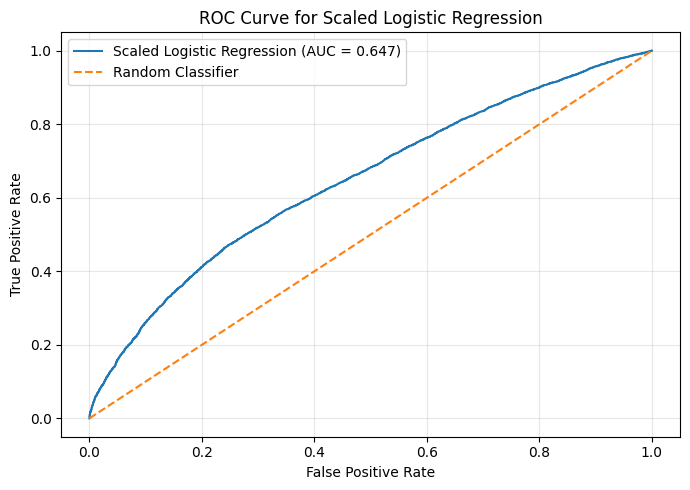

Scaled Logistic Regression ROC-AUC: 0.6473


In [63]:
# Import ROC evaluation tools
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve values
fpr_scaled, tpr_scaled, thresholds_scaled = roc_curve(
    y_test,
    y_prob_scaled
)

# Calculate ROC-AUC
scaled_roc_auc = roc_auc_score(
    y_test,
    y_prob_scaled
)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_scaled,
    tpr_scaled,
    label=f"Scaled Logistic Regression (AUC = {scaled_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Scaled Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()

print("Scaled Logistic Regression ROC-AUC:", round(scaled_roc_auc, 4))

## 5B. ROC Curve Analysis

The ROC curve is above the diagonal line representing random classification, showing that the logistic regression model can distinguish between readmitted patients and those who were not readmitted.

The model produced a ROC-AUC of 0.6473. An AUC of 0.50 corresponds to random classification, whereas values closer to 1.00 indicate greater discriminatory performance. As a result, an AUC of 0.6473 suggests modest discriminatory ability.

Although the model performs better than random classification, the ROC curve and AUC indicate that the seven healthcare utilization predictors do not provide strong separation between readmitted and non-readmitted patients. Additional patient characteristics or clinical variables could potentially improve prediction.

## 5C. Comparison of Baseline and Scaled Models

### Objective

This subsection compares the baseline logistic regression model's predictive performance with that of the scaled logistic regression model.

Both models are evaluated using the same test set and performance metrics. This comparison will examine whether standardizing the predictor variables resulted in meaningful changes in classification performance.

In [64]:
# Calculate baseline model metrics using the corrected baseline predictions
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)

# Create baseline vs. scaled comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Scaled Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        scaled_accuracy
    ],
    "Precision": [
        baseline_precision,
        scaled_precision
    ],
    "Recall": [
        baseline_recall,
        scaled_recall
    ],
    "F1-score": [
        baseline_f1,
        scaled_f1
    ],
    "ROC-AUC": [
        baseline_auc,
        scaled_roc_auc
    ]
})

print("Baseline vs. Scaled Logistic Regression:")
display(model_comparison.round(4))

Baseline vs. Scaled Logistic Regression:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline Logistic Regression,0.6191,0.6448,0.3863,0.4832,0.6473
1,Scaled Logistic Regression,0.6191,0.6449,0.3864,0.4833,0.6473


### 5C. Analysis

The baseline and scaled logistic regression models produced nearly identical classification performance.

The baseline model had an accuracy of 0.6191, precision of 0.6448, recall of 0.3863, F1-score of 0.4832, and ROC-AUC of 0.6473. After standardization, the scaled model maintained an accuracy of 0.6191 and ROC-AUC of 0.6473, while precision increased slightly to 0.6449, recall to 0.3864, and F1-score to 0.4833.

These differences are relatively minor and do not indicate a meaningful improvement in predictive performance. In this analysis, standardizing the seven predictor variables had a minimal impact on the logistic regression model's classification performance.

Although scaling did not meaningfully improve predictive performance, it placed predictors measured on different numerical scales on a common scale. This is especially relevant when comparing the magnitudes of the standardized logistic regression coefficients in Section 6. Because scikit-learn's logistic regression applies regularization by default, feature scaling may also influence how the regularization penalty is applied across predictors. Therefore, the small differences between the baseline and scaled models may reflect both predictor standardization and its interaction with the model's default regularization.

# 6. Logistic Regression Coefficient Interpretation

## 6A. Model Coefficients

### Objective

The objective of this section is to assess the scaled logistic regression model's coefficients in order to determine the direction and relative strength of the association between each predictor and hospital readmission.

Because the predictors were standardized prior to model fitting, the coefficients can be compared on a similar scale. Positive coefficients indicate increased log-odds of readmission as the predictor increases, whereas negative coefficients indicate lower log-odds of readmission when all other predictors are held constant.

In [65]:
# Extract coefficients from the scaled logistic regression model
coefficient_table = pd.DataFrame({
    "Predictor": features,
    "Coefficient": scaled_logistic_model.coef_[0]
})

# Sort coefficients from largest to smallest
coefficient_table = coefficient_table.sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)

print("Scaled Logistic Regression Coefficients:")
display(coefficient_table.round(4))

Scaled Logistic Regression Coefficients:


,Predictor,Coefficient
0,number_inpatient,0.4697
1,number_emergency,0.1976
2,number_diagnoses,0.1648
3,number_outpatient,0.1112
4,num_medications,0.0428
5,num_lab_procedures,0.0336
6,num_procedures,-0.0920


### 6A. Analysis

The scaled logistic regression coefficients show that six of the seven predictors were positively associated with hospital readmission, while `num_procedures` had a negative association. Among the standardized predictors, `number_inpatient` had the strongest positive association (0.4697). This was followed by `number_emergency` (0.1976), `number_diagnoses` (0.1648), and `number_outpatient` (0.1112).

`num_medications` (0.0428) and `num_lab_procedures` (0.0336) exhibited smaller positive coefficients, indicating weaker positive associations with readmission.

In contrast, `num_procedures` exhibited a coefficient of -0.0920, indicating a negative association with readmission when the other predictors were held constant.

Because all predictors were standardized, the coefficient magnitudes can be compared on a common scale. Overall, among the seven predictors, previous inpatient utilization had the largest positive association with hospital readmission.

## 6B. Odds Ratios

### Objective

The objective of this subsection is to convert the standardized logistic regression coefficients into odds ratios, which provide a more interpretable assessment of the association between each predictor and hospital readmission.

An odds ratio greater than one indicates that higher values of the predictor are associated with higher odds of readmission, whereas an odds ratio less than one indicates lower odds of readmission. Because the predictors were standardized, each odds ratio represents the change in the odds of readmission associated with a one-standard-deviation increase in the corresponding predictor, while holding the other predictors constant.

In [66]:
# Calculate odds ratios from the scaled logistic regression coefficients
odds_ratio_table = coefficient_table.copy()

odds_ratio_table["Odds Ratio"] = np.exp(
    odds_ratio_table["Coefficient"]
)

print("Scaled Logistic Regression Odds Ratios:")
display(odds_ratio_table.round(4))

Scaled Logistic Regression Odds Ratios:


,Predictor,Coefficient,Odds Ratio
0,number_inpatient,0.4697,1.5995
1,number_emergency,0.1976,1.2185
2,number_diagnoses,0.1648,1.1791
3,number_outpatient,0.1112,1.1176
4,num_medications,0.0428,1.0438
5,num_lab_procedures,0.0336,1.0341
6,num_procedures,-0.0920,0.9121


### 6B. Analysis

Odds ratios provide a more interpretable measure of the associations between standardized predictors and hospital readmission. `number_inpatient` had the highest odds ratio of 1.5995. A one-standard-deviation increase in previous inpatient visits was associated with approximately 60.0% higher odds of hospital readmission, holding other predictors constant. The odds ratio for `number_emergency` was 1.2185, corresponding to approximately 21.9% higher odds of readmission. Similarly, `number_diagnoses` had an odds ratio of 1.1791, indicating approximately 17.9% higher odds, and `number_outpatient` had an odds ratio of 1.1176, corresponding to approximately 11.8% higher odds of readmission.

Smaller positive associations were observed for `num_medications` and `num_lab_procedures`, with odds ratios of 1.0438 and 1.0341, respectively.

In contrast, the odds ratio for `num_procedures` was 0.9121. This indicates that a one-standard-deviation increase in the number of procedures was associated with approximately 8.8% lower odds of readmission, while holding the other predictors constant.

Overall, among the seven predictors, previous inpatient utilization had the largest positive association with hospital readmission. These findings reflect associations within the fitted logistic regression model and should not be interpreted as causal effects.

# 7. Final Conclusion

The Week 4 analysis applied logistic regression and feature scaling to predict hospital readmission among patients with diabetes. The original readmission outcome was transformed into a binary variable distinguishing between patients who were readmitted and those who were not. Seven predictors related to healthcare utilization and hospital encounters were used to predict the outcome.

The baseline logistic regression model attained an accuracy of 0.6191, precision of 0.6448, recall of 0.3863, F1-score of 0.4832, and ROC-AUC of 0.6473. The relatively low recall indicates that the baseline model did not correctly identify a substantial proportion of patients who were actually readmitted. The confusion matrix supported this observation, showing 5,757 false negatives compared with 3,624 true positives.

Feature scaling effectively standardized the seven predictors to a common scale. The scaled logistic regression model attained an accuracy of 0.6191, precision of 0.6449, recall of 0.3864, F1-score of 0.4833, and ROC-AUC of 0.6473. Compared with the baseline model, scaling produced only minor changes in precision, recall, and F1-score, while accuracy and ROC-AUC remained the same to four decimal places. Consequently, feature scaling did not meaningfully improve predictive performance in this analysis.

The analysis of standardized coefficients and odds ratios indicated that previous inpatient utilization had the strongest positive association with hospital readmission. A one-standard-deviation increase in `number_inpatient` was associated with approximately 60.0% higher odds of readmission, holding the other predictors constant. `number_emergency`, `number_diagnoses`, and `number_outpatient` also exhibited positive associations with readmission. Conversely, a one-standard-deviation increase in `num_procedures` was associated with approximately 8.8% lower odds of readmission, holding the other predictors constant.

The logistic regression models exhibited modest ability to distinguish between readmitted and non-readmitted patients, as indicated by a ROC-AUC of 0.6473. The low recall indicates that the seven predictors alone were not sufficient to identify many patients who were readmitted. Future analyses could explore additional demographic, clinical, and treatment-related predictors, as well as alternative classification approaches, to determine whether readmission prediction can be improved. The associations identified in this analysis should not be interpreted as causal effects.